In [1]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
import matplotlib.pyplot as plt
import scipy


import sys
sys.path.append('bk_terms/')
sys.path.append('Library/')

#import functions 
from WS_cosmo import *
from useful_funcs import *

# Import the plot style settings
import Library.plot_style#%run Library/plot_style          #
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('font', size='22')

# compute cosmology with class

In [2]:
#import and define cosmlogy in class
from classy import Class

#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

# So we need to also define survey specific parameters like biases

In [14]:
#load in preset surveys 
survey_params = SurveyParams(cosmo)
Euclid_dict = survey_params.get_surveybias('Euclid')
BGS_dict = survey_params.get_surveybias('BGS')
SKAO1_dict = survey_params.get_surveybias('SKAO1')
SKAO2_dict = survey_params.get_surveybias('SKAO2')

#in which we define linear_bias, survey redshifts,evolution and magnification bias as well as number density and f_sky
#print(Euclid_dict)

# second order bias and tidal bias are define wrt to b_1


## Import expression for each contributions

In [5]:
from WA1 import *    #first order WA
from WA2 import *    #second order WA etc
from RR1 import *
from RR2 import *
from WARR import *

from WSGR import *   #contains WAGR and RRGR 
from GR0 import *
from GR1 import *
from GR2 import *
from PNG import *

from cov import COV as COV # covariances for some multipoles

In [22]:
#see the multipoles are defined - not all computed and stored in bk_terms
dir(WA1)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'l1',
 'l1m1',
 'l3',
 'l3m1',
 'l3m2',
 'l3m3']

### CosmologicalFunctions takes in the cosmology and survey_params 

In [16]:
#so now we can compute terms for this cosmology and for euclid-likes biases
cosmo_functions = CosmologicalFunctions(cosmo,survey_params=Euclid_dict)

now all parameters we need are computable from cosmo_functions - lets look at an example

In [ ]:
#so now we set bispectrum as a function of k1,k2,theta and z

zz=1 # redshift

#so lets look at the bispectrum as function of theta for fixed k1 and k2 

k1=0.04
k2=k1/2
theta = np.linspace(0,np.pi,200)
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

Everything is vectorised so - we can always create meshes to compute the bispectrum over different scales and shapes

In [ ]:
#then we can access the terms we need which are returned as a list (they dont need to be unpacked!)
params = cosmo_functions.get_params(k1,k2,theta,zz)#base set of parameters
k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2=params

derivs = cosmo_functions.get_derivs(zz)#derivates with respect to commoving distance 
fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1 = derivs

betas = cosmo_functions.get_beta_funcs(zz)#redshift dependent betas for relativistic parts
gr1,gr2,grd1,beta6,beta7,beta8,beta9,beta10,beta11,beta12,beta13,beta14,beta15,beta16,beta17,beta18,beta19,betad14,betad15,betad16,betad17,betad18,betad19=betas

PNGparams = cosmo_functions.get_PNGparams(fNL,zz,k1,k2,k3)# and parameters needed for the local primoridal non-Gaussianity
fNL,bE01,bE11,bE02,alphak1,alphak2,alphak3 = PNGparams

In [ ]:
"""
so for the functions
#WA.l1(params,r,s)
#RR.l1(params,derivs,r,s)
#GR.l1(params,betas)

and mixed terms need everything with this ordering
#RRGR.l0(params,derivs,betas,r,s)
"""

## So now we have everything we need 

Text(0, 0.5, '$ \\text{Imag}[B_{\\ell=1}(k1=0.04,k2=0.02)] $')

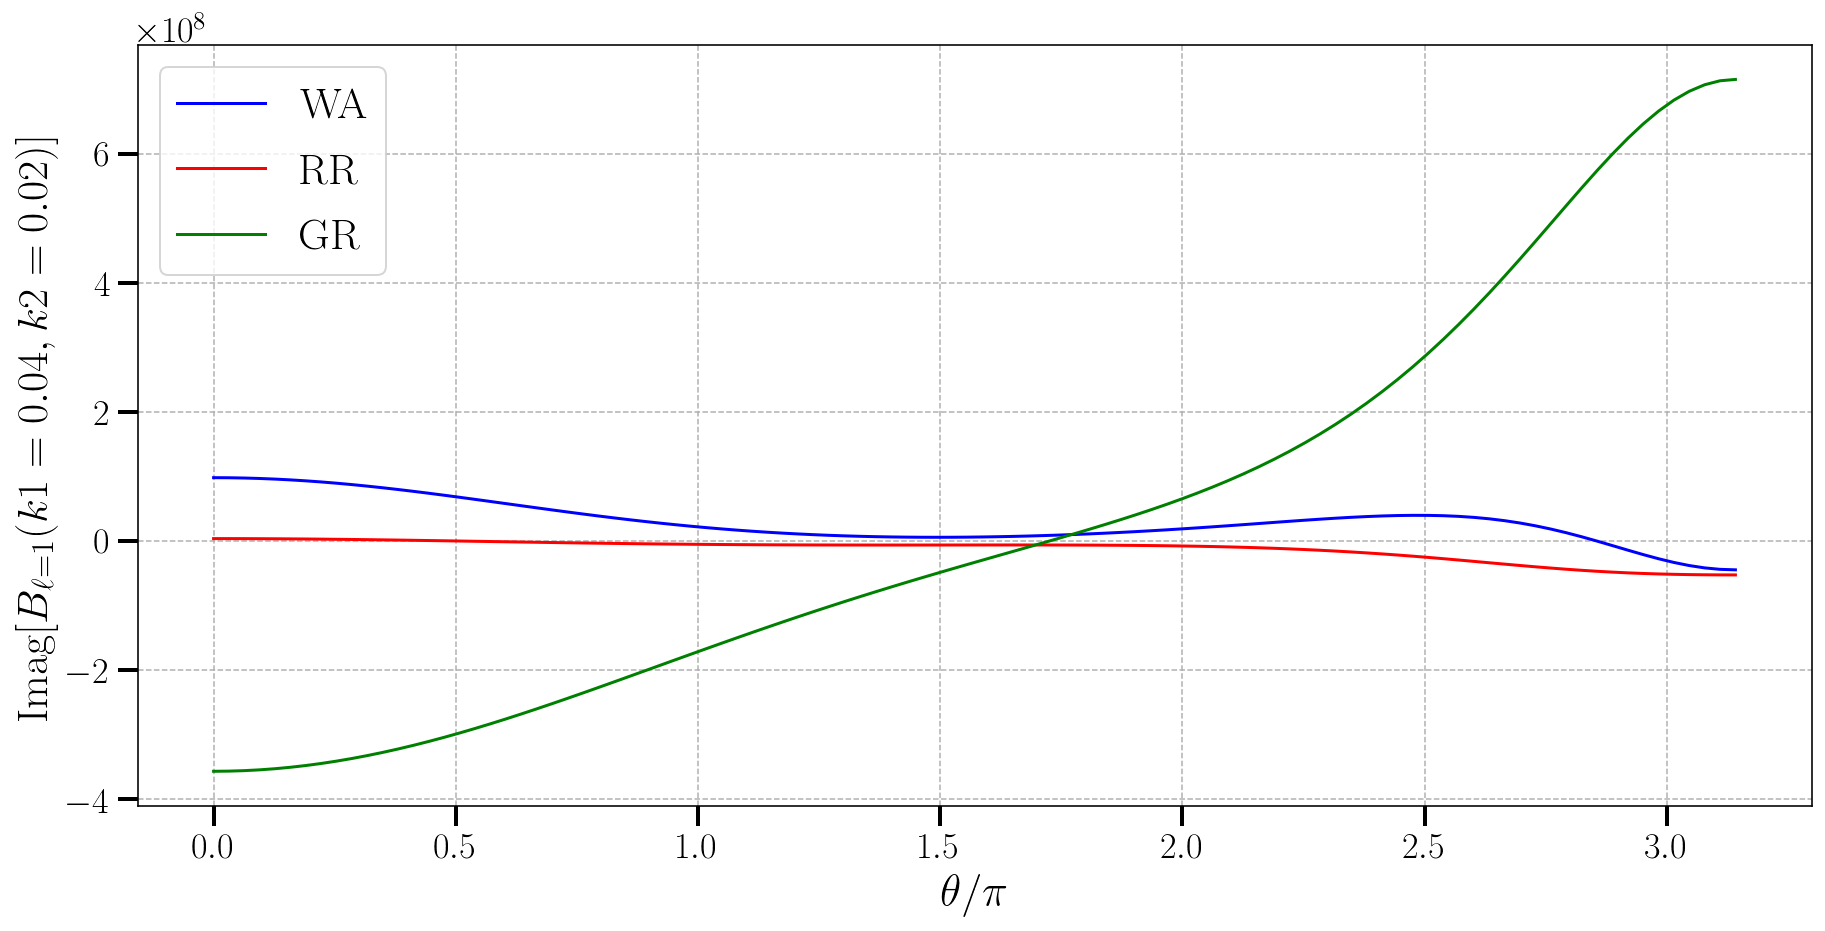

In [23]:
#also set LOS to d = x_3
r=s=0

plt.figure(figsize=(15,7))

#
plt.plot(theta,WA1.l1(params,r,s).imag,color='blue',label='WA')
plt.plot(theta,RR1.l1(params,derivs,r,s).imag,color='red',label='RR')
plt.plot(theta,GR1.l1(params,betas).imag,color='green',label='GR')

plt.legend()
plt.grid(ls='--',lw=0.75)
plt.xlabel(r'$\theta/ \pi\,$')
plt.ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.04,k2=0.02)] $')

Text(0, 0.5, '$ \\text{Imag}[B_{\\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

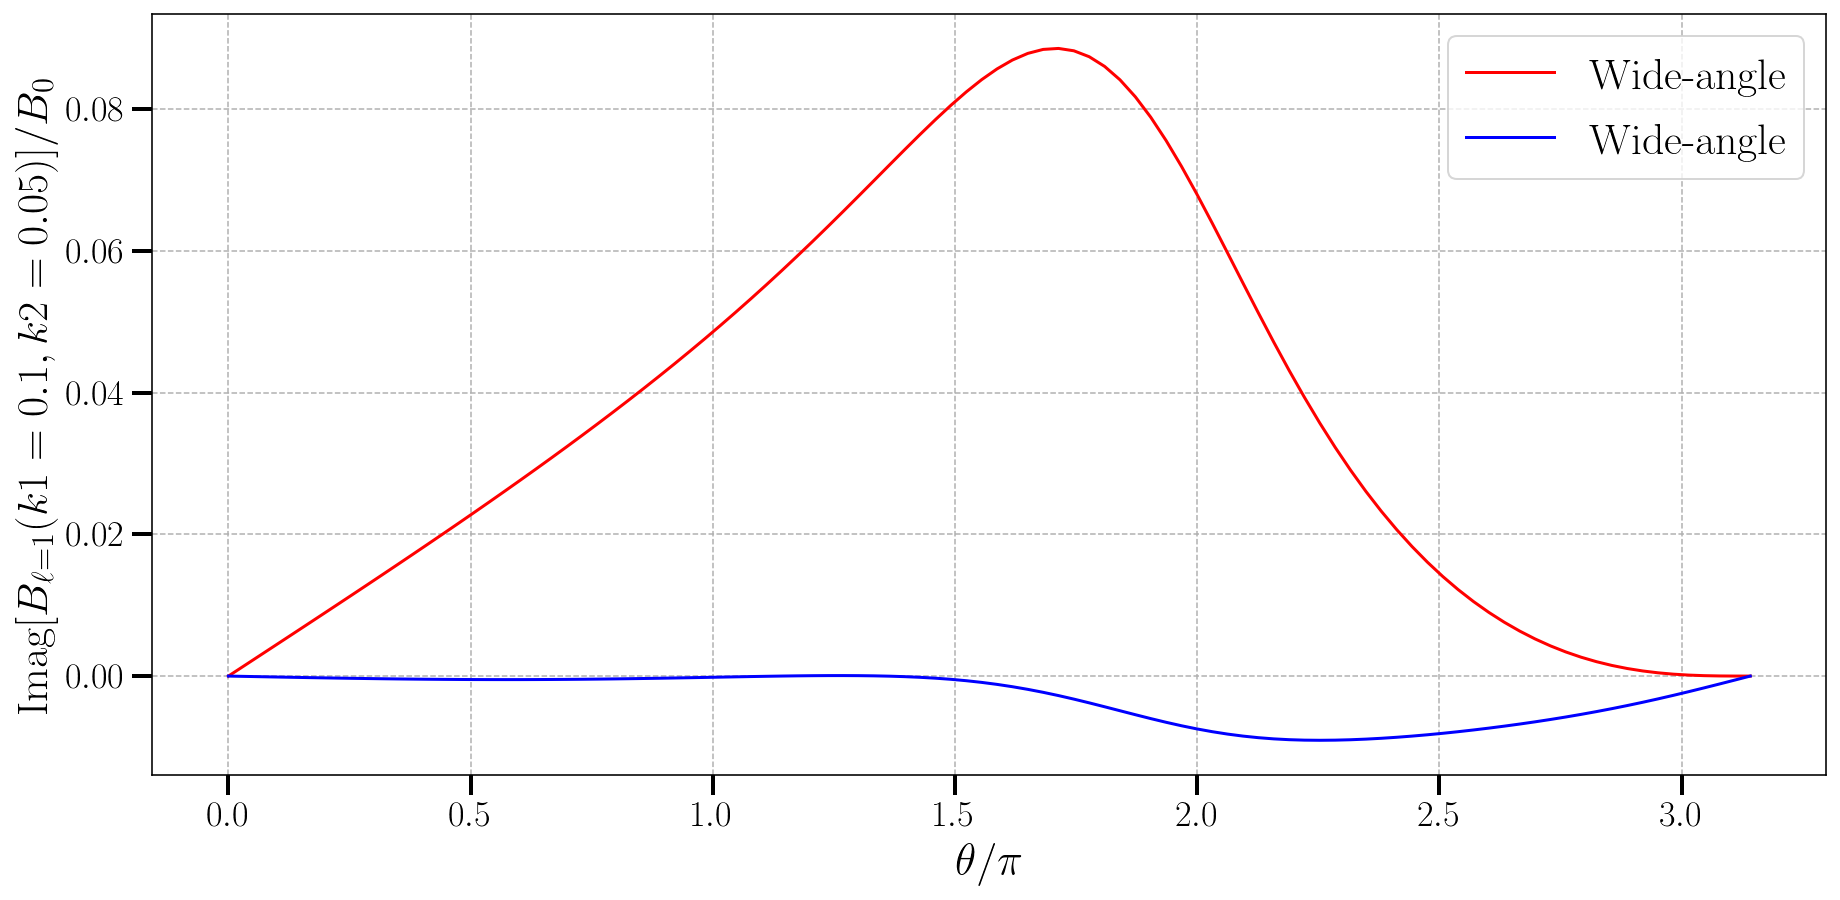

In [10]:
plt.figure(figsize=(15,7))

#ok get some equilateral triangles...
if False:
    k1 = np.geomspace(1e-4,1,1000)
    k2 = 0.9*k1
    k3 = 0.5*k1
    theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
else:
    k1=0.04;k2=k1/2
    theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))


theta_= theta[..., None, None]

zz=1

cosmo_functions = CosmologicalFunctions(cosmo,survey_params=Euclid_dict)
params = cosmo_functions.get_params(k1,k2,theta,zz)
params2 = cosmo_functions.get_params(k1,k2,theta_,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)



r=0;s=0
#plt.plot(theta,(RR1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='red',label='RR')
#plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')
plt.plot(theta,GR1.l1m1(params,betas).imag/GR0.l0(params),'-',color='red',label='Wide-angle')
plt.plot(theta,RR1.l1m1(params,derivs,r,s).imag/GR0.l0(params),'-',color='blue',label='Wide-angle')
#plt.plot(theta,numeric_ylm(WA.full_1,1,1,params=params2,dfog=False,type_=0).imag/GR0.l0(params),'--',color='black')

#plt.ylim(-1,1)
#plt.xlim(0,1)
plt.grid(ls='--',lw=0.75)

plt.legend()
plt.xlabel(r'$\theta/ \pi\,$')
plt.ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')

In [27]:
zz=1

k1 = np.linspace(0.05,0.1)
k3 = k1
k2= 0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

#cosmo_functions = CosmologicalFunctions(cosmo,'BGS')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(100,zz,k1,k2,k3)

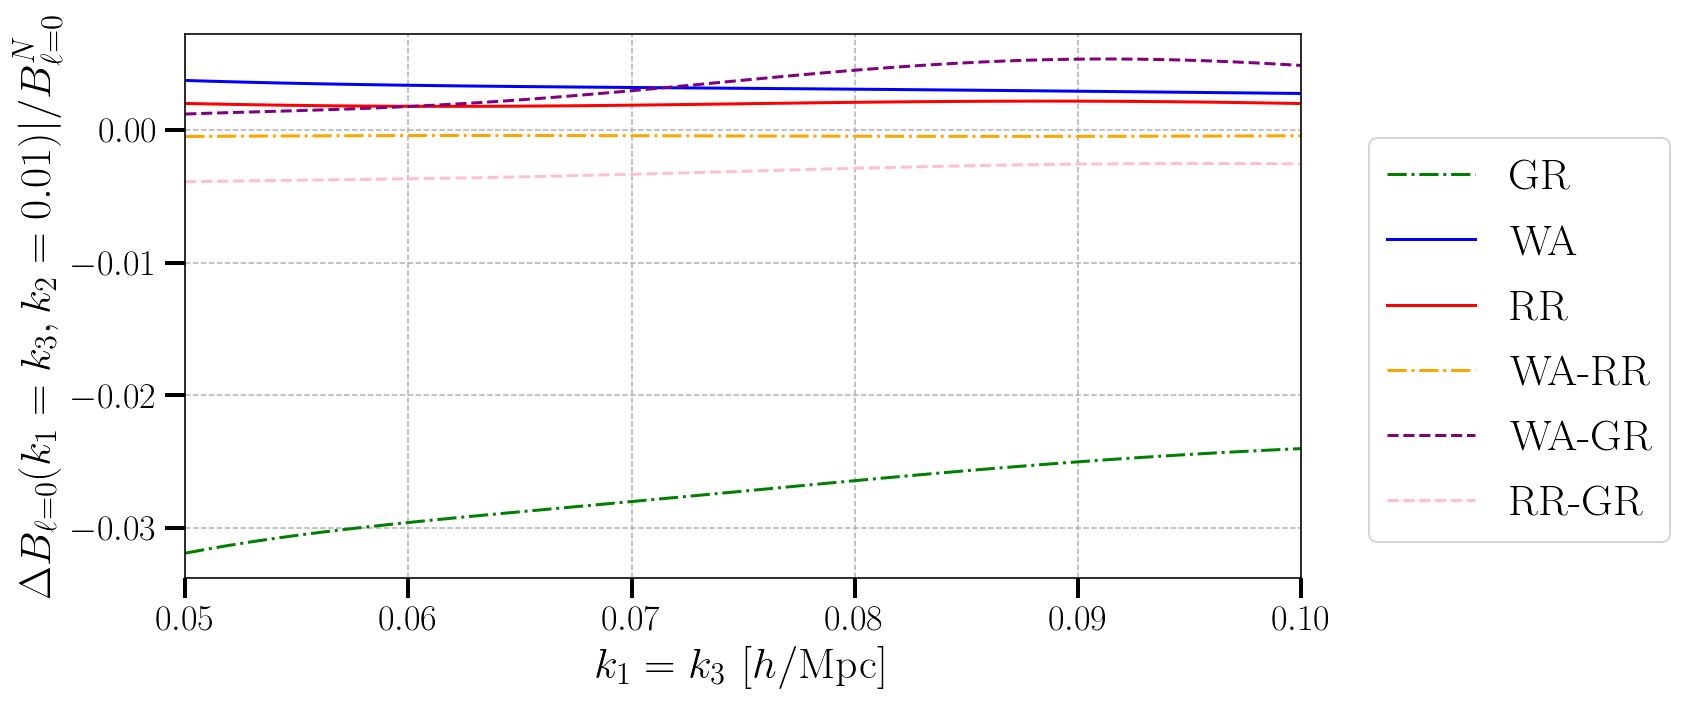

In [26]:
#so lets plot monopole...
plt.figure(figsize=(10,5))
r=0;s=0

justWS=WA2.l0(params,r,s)+RR2.l0(params,derivs,r,s)+WARR.l0(params,derivs,r,s)
#totalws = justwaRR+WAGR.l0(params,betas,r,s)+RRGR.l0(params,derivs,betas,r,s)
plt.plot(k3,GR2.l0(params,betas)/2/GR0.l0(params),'-.',label='GR',color='green')

plt.plot(k3,WA2.l0(params,r,s)/GR0.l0(params),'-',label='WA',color='blue')
plt.plot(k3,RR2.l0(params,derivs,r,s)/GR0.l0(params),'-',label='RR',color='red')
plt.plot(k3,WARR.l0(params,derivs,r,s)/GR0.l0(params),'-.',label='WA-RR',color='orange')

plt.plot(k3,WAGR.l0(params,betas,r,s)/GR0.l0(params),'--',label='WA-GR',color='purple')
plt.plot(k3,RRGR.l0(params,derivs,betas,r,s)/GR0.l0(params),'--',label='RR-GR',color='pink')

#plt.plot(k3,totalwa/GR0.l0(params),'--',color='black',label='RR+WA')
#plt.plot(k3,justwaRR/GR0.l0(params),'-',color='red',label='RR+WA')
#plt.plot(k3,total/GR0.l0(params),label='RR+WA+GR',color='black')
plt.xlabel('$ k_1=k_3 \,\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$\Delta B_{\ell=0}(k_1=k_3,k_2=0.01)|/B^N_{\ell=0}$')
#plt.plot(k3,np.zeros_like(k3),'--', color='black')
#plt.text(0.1,0.6,r"z=0.4 - DESI-like")
plt.xlim(0.05,0.10)
plt.legend(bbox_to_anchor=(0.85, 0.35, 0.5, 0.5))
plt.grid(ls='--',lw=0.75)
#plt.ylim(0,0.003)
plt.savefig('plots/second_order_lots.png', bbox_inches='tight', dpi=400)
plt.show()

In [ ]:
from matplotlib.patches import Polygon
def plot_3x2(first=True):
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

    # Create subplots with custom aspect ratios
    #axs = [fig.add_subplot(gs[0, i], aspect='10') for i in range(2)]  # Subplots in the first row

    #horizonatally
    for i in range(2):
        axs[0,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)
        axs[1,i].get_xaxis().set_tick_params(which='both', size=0, labelsize=0)

    #vertically
    for i in range(3):
        axs[i,0].set_xticks(np.arange(0.1, 0.59, 0.2))
        axs[i,1].set_xticks(np.arange(0.9, 1.81, 0.3))

        #set triangle
        if i ==0: #
            k1 = 0.01
            k2 = k3 = k1
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        elif i==1: # folded
            k1 = 0.02
            k2 = k3 = 0.01
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
        else: #squeezed
            k1 = k2 = 0.05
            k3 = 0.005
            theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

        for j in range(2):
            #choose which survey
            if j ==0:
                cosmo_functions = CosmologicalFunctions(cosmo,survey_params=BGS_dict)#SKAO2
                axs[0,j].text(0.25,1.1,'DESI-like BGS',fontsize=20)
            else:
                cosmo_functions = CosmologicalFunctions(cosmo,survey_params=Euclid_dict)
                axs[0,j].text(1.15,1.1,r'Euclid-like H$\alpha$',fontsize=20)
            z_plot = cosmo_functions.z_survey

            params = cosmo_functions.get_params(k1,k2,theta,z_plot)
            derivs = cosmo_functions.get_derivs(z_plot)
            betas = cosmo_functions.get_beta_funcs(z_plot)

            norm = GR0.l0(params)
            
            #plot different contributions
            if first:#for first order stuff
                r=0;s=0
                axs[i,j].set_ylim(1.0001e-3,.9)
                axs[i,j].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',linewidth=3,label='GR',color=colors[1])
                axs[i,j].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'-',linewidth=2.25,label='WA',color=colors[0])
                axs[i,j].plot(z_plot,np.abs(RR1.l1(params,derivs,r,s)/norm),'-',linewidth=1.5,label='RR',color=colors[2])
                axs[1,0].set_ylabel('$|B_{(1,0)}|/B^N_{(0,0)}$')
                axs[0,1].legend(ncol=3,frameon=False,title_fontsize=12,handlelength=1,columnspacing=1,handleheight=0.5, borderpad=0)

            else:#for second order stuff
                r=s=1/3
                axs[i,j].set_ylim(5e-4,.9)#axs[i,j].set_ylim(5e-3,2)#
                #axs[i,j].plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
                #axs[i,j].plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
                if i ==0 and j ==0:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',label='GR',color=colors[1])

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',label='WA',color=colors[0])
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',label='RR',color=colors[2])
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',label='WA/RR',color=colors[3])

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',label='WA/GR',color=colors[4])
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',label='RR/GR',color=colors[5])
                else:
                    axs[i,j].plot(z_plot,np.abs(GR2.l0(params,betas)/norm),'-',color=colors[2])

                    axs[i,j].plot(z_plot,np.abs(WA2.l0(params,r,s)/norm),'-',color=colors[0])
                    axs[i,j].plot(z_plot,np.abs(RR2.l0(params,derivs,r,s)/norm),'-',color=colors[1])
                    axs[i,j].plot(z_plot,np.abs(WARR.l0(params,derivs,r,s)/norm),'--',color=colors[3])

                    axs[i,j].plot(z_plot,np.abs(WAGR.l0(params,betas,r,s)/norm),'-.',color=colors[4])
                    axs[i,j].plot(z_plot,np.abs(RRGR.l0(params,derivs,betas,r,s)/norm),'-.',color=colors[5])

                axs[1,0].set_ylabel('$|\Delta B_{(0,0)}|/B^N_{(0,0)}$')
                fig.legend(loc=[0.05,0.95],ncol=6,frameon=False,title_fontsize=12,handlelength=1, columnspacing=1, handleheight=0.5, borderpad=0)
                #xs[0,1].legend(ncol=1,frameon=False,title_fontsize=15,handlelength=1.1, handleheight=0.5, borderpad=0)

            
            #we plot scale where it breaks down
            chi = 2*np.pi/k3
            axs[i,0].vlines(cosmo_functions.d_to_z(chi),0,1e+10,linestyles='--',color='black',alpha=1)
            
            axs[i,j].set_yscale('log')
            
            axs[i, j].grid(ls='--', lw=0.75, color='k', alpha=0.2)
            
            axs[2,j].set_xlabel('$z$')
                        
            axs[i,1].get_yaxis().set_tick_params(which='both', size=0, labelsize=0)
            
    
    def triple_triangle_coords(base_x=0.4,base_y=0.5):
        triangle_coords = {
            0: np.array([[base_x+0.05, base_y +0.1-0.3*np.sin(np.pi/3)], [base_x+0.2, base_y+0.1], [base_x+0.35, base_y +0.1-0.3*np.sin(np.pi/3)]]),  # Equilateral triangle
            1: np.array([[base_x, base_y-0.05], [base_x+0.2, base_y+0.05], [base_x+0.4, base_y-0.05]]),  # Folded triangle
            2: np.array([[base_x, base_y-0.05], [base_x+0.4, base_y+0.05], [base_x+0.4, base_y-0.05]])   # Squeezed triangle
        }
        return triangle_coords
    
    triangle_labels = {0: 'Equilateral', 1: 'Folded', 2: 'Squeezed'}
    
    base_x,base_y = 0.4,0.5
    # Plot the triangles on the additional axis
    for i in range(3):
        
        # Create an additional axis for the triangles
        ax_triangles = fig.add_axes([0.8, 0.6-0.25*i, 0.3, 0.3], frameon=False)
        ax_triangles.set_xticks([])
        ax_triangles.set_yticks([])
    
        triangle = Polygon(triple_triangle_coords(0.4,0.5)[i], closed=True, fill=None, edgecolor='black')
        ax_triangles.add_patch(triangle)
        ax_triangles.text(base_x, base_y+0.15, triangle_labels[i])

    fig.subplots_adjust(hspace=0)
    fig.subplots_adjust(wspace=0)
    if first:
        plt.savefig('plots/redshift_first.png', bbox_inches='tight', dpi=400)
    else:
        plt.savefig('plots/redshift_second.png', bbox_inches='tight', dpi=400)

#plot_3x2(False)